In [17]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [18]:
load_dotenv()

True

In [19]:
model = ChatOpenAI()

In [20]:
class ChatState(MessagesState):
    summary: str

In [21]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [22]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [23]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [24]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [25]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

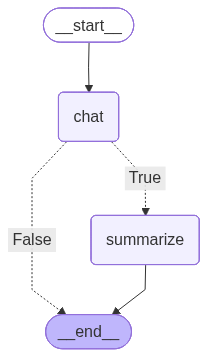

In [26]:
graph

In [27]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [28]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [29]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='6bfd4888-23b2-46b0-8281-567a1944edef')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is the branch of physics that 


In [30]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='6bfd4888-23b2-46b0-8281-567a1944edef'), AIMessage(content='Quantum physics, also known as quantum mechanics, is the branch of physics that deals with the behavior of very small particles such as atoms and subatomic particles. It describes how these particles interact with each other and with the energy that surrounds them.\n\nOne of the key principles of quantum physics is the wave-particle duality, which states that particles can exhibit both wave-like and particle-like behavior depending on the experimental setup. This duality is captured in the famous Schrödinger equation, which describes the probability distribution of a particle in a given state.\n\nQuantum physics also introduces the concept of superposition, where a particle can exist in multiple states at the same time until it is measured or observed. This can lead to phenomena such as quantum entanglement, where particles become interconn

In [31]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='6bfd4888-23b2-46b0-8281-567a1944edef'), AIMessage(content='Quantum physics, also known as quantum mechanics, is the branch of physics that deals with the behavior of very small particles such as atoms and subatomic particles. It describes how these particles interact with each other and with the energy that surrounds them.\n\nOne of the key principles of quantum physics is the wave-particle duality, which states that particles can exhibit both wave-like and particle-like behavior depending on the experimental setup. This duality is captured in the famous Schrödinger equation, which describes the probability distribution of a particle in a given state.\n\nQuantum physics also introduces the concept of superposition, where a particle can exist in multiple states at the same time until it is measured or observed. This can lead to phenomena such as quantum entanglement, where particles become interconn

In [32]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='6bfd4888-23b2-46b0-8281-567a1944edef'), AIMessage(content='Quantum physics, also known as quantum mechanics, is the branch of physics that deals with the behavior of very small particles such as atoms and subatomic particles. It describes how these particles interact with each other and with the energy that surrounds them.\n\nOne of the key principles of quantum physics is the wave-particle duality, which states that particles can exhibit both wave-like and particle-like behavior depending on the experimental setup. This duality is captured in the famous Schrödinger equation, which describes the probability distribution of a particle in a given state.\n\nQuantum physics also introduces the concept of superposition, where a particle can exist in multiple states at the same time until it is measured or observed. This can lead to phenomena such as quantum entanglement, where particles become interconn